In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import sqlite3

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, normaltest, skew, kurtosis

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

%matplotlib inline

In [2]:

# 1. Connect to SQLite (This creates 'my_database.db' automatically if it doesn't exist)
conn = sqlite3.connect('logistics_heavy.db')

# 2. Load the CSV file into a Pandas DataFrame
df = pd.read_csv('logistics_heavy.csv')

# 3. Push the data to SQLite
# 'if_exists="replace"' creates the table automatically. Use 'append' if adding to an existing table.
df.to_sql('logistic', conn, if_exists='replace', index=False)

# 4. Close the connection
conn.close()
print("Successfully loaded 400k rows into SQLite!")

Successfully loaded 400k rows into SQLite!


In [3]:
# Display first few rows
print("First 10 rows of the dataset:")
display(df.head(10))

First 10 rows of the dataset:


,shipment_id,order_id,customer_name,origin_city,destination_city,origin_country,destination_country,ship_date,delivery_date,weight_kg,volume_m3,shipping_mode,status,base_cost_usd,surcharge_usd,total_cost_usd,currency,payment_terms,created_at,last_update
0,SHP-288390,53737,nguyen kim,Phnom Penh,Saigon,TH,Cambodia,"Oct 15, 2021","Jan 14, 2021",301.9,2.50,rail,LOST,1259.14,726.46,2305.8,THB,PrePaid,2023-02-21T13:50:23Z,2023-07-06T05:55:19Z
1,74871,382273,Vann Lee,Bangkok,Phnom Penh,Cambodia,VN,05/14/2022,08/08/2021,269.53,1.86,TRK,DELIVERED,"99,0",free,NaN,NaN,cod,2023-10-11 00:25:04,2023-10-02T09:42:53Z
2,918399,ORD-399488,Dara Smith,Bangkok,Phnompenh,NaN,Vietnam,04/03/2021,2020-11-18,488.99,2.65,trk,DELIVERED,849.16,1080.9,error,usd,cod,29/10/2023 20:10,2023-05-07 08:10:51
3,SHP-070675,ORD-37150,Nguyen Lee,HCMC,HCMC,Thailand,VN,"Aug 10, 2024","Sep 05, 2020",54.72,3.52,Air Freight,INTRANSIT,155.39,1712.65,1868.04,NaN,prepaid,2023-04-20 14:36:05,2023-05-02 06:03:18
4,823268,ORD-382996,Nguyen Garcia,Phnom Penh,Phnom Penh,VNM,NaN,2025-09-11,NaN,201.95,1.77,air,LOST,636.16,1341.1,1977.2599999999998,KHR,credit 30d,2023-02-07 00:20:20,2023-10-16 03:38:24
5,72133,82705,Maria Smith,Phnom Penh,BKK,KH,KHM,14/03/21,"Dec 17, 2022",25.49,1.77,NaN,DELIVERED,1483.76,858.24,3239.24,KHR,PrePaid,2023-10-10 05:23:30,2023-06-07 13:16:35
6,SHP-818012,ORD-325406,Dara Lee,Phnom Penh,Ho Chi Minh,VN,Thailand,"Mar 18, 2021",02/28/2025,NaN,3.58,truck,Delivered,1284.76,1962.39,3247.15,USD,credit 30d,2023-05-16 01:23:34,2023-06-26 11:25:14
7,267096,NaN,John Kim,Bangkok,PP,Vietnam,KH,05/15/2023,"Feb 24, 2022",374.09,2.77,TRK,delivered,1572.59,647.89,2220.48,NaN,PrePaid,2023-12-04T03:05:14Z,2023-11-21T22:32:47Z
8,845743,128369,maria smith,Bangkok,Saigon,Thailand,Cambodia,"Mar 12, 2021",2022-10-17,333.82,1.53,trk,RETURNED,894.6,1723.68,2618.28,usd,PrePaid,2023-11-17T08:42:38Z,01/01/2024 10:24
9,SHP-242496,112173,Chan Tran,Saigon,Phnom Penh,VN,Vietnam,"May 16, 2024",22/06/25,194.49,2.54,Air Freight,DELIVERED,1814.32,1327.68,3142.0,VND,credit 30d,2023-07-14 10:07:51,2023-04-19T16:33:18Z


In [4]:
# Dataset information
print("Dataset Info:")
print("="*60)
df.info() 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   shipment_id          360002 non-null  object 
 1   order_id             339961 non-null  object 
 2   customer_name        372181 non-null  object 
 3   origin_city          388144 non-null  object 
 4   destination_city     387894 non-null  object 
 5   origin_country       337830 non-null  object 
 6   destination_country  337802 non-null  object 
 7   ship_date            388076 non-null  object 
 8   delivery_date        359616 non-null  object 
 9   weight_kg            380039 non-null  object 
 10  volume_m3            360064 non-null  float64
 11  shipping_mode        379958 non-null  object 
 12  status               388216 non-null  object 
 13  base_cost_usd        400000 non-null  object 
 14  surcharge_usd        400000 non-null  object 
 15  tot

In [5]:
# Statistical summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,volume_m3
count,360064.00
mean,2.02
std,0.96
min,0.00
25%,1.33
50%,2.00
75%,2.67
max,6.56


In [6]:
# Categorical columns summary
print("Categorical Columns Summary:")
display(df.describe(include=['object']))

Categorical Columns Summary:


,shipment_id,order_id,customer_name,origin_city,destination_city,origin_country,destination_country,ship_date,delivery_date,weight_kg,shipping_mode,status,base_cost_usd,surcharge_usd,total_cost_usd,currency,payment_terms,created_at,last_update
count,360002,339961,372181,388144,387894,337830,337802,388076,359616,380039,379958,388216,400000,400000,328569,317313,315302,400000,400000
unique,325170,286193,324,8,8,8,8,8769,8769,64264,9,10,203512,203639,194943,5,6,382634,382475
top,646438,ORD-224932,Sok Lee,BKK,PP,VN,KHM,32/13/2024,32/13/2024,unknown,air,in transit,free,free,error,USD,COD,0000-00-00,0000-00-00
freq,5,6,5195,48750,48647,42499,42491,3813,3476,18977,42469,39007,8088,8165,71545,63842,52797,8033,8110


### Missing Values Analysis

In [7]:
# Missing values count and percentage
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

print("Missing Values Summary:")
print("="*60)
display(missing_data)

Missing Values Summary:


,Missing_Count,Missing_Percentage
payment_terms,84698,21.17
currency,82687,20.67
total_cost_usd,71431,17.86
destination_country,62198,15.55
origin_country,62170,15.54
order_id,60039,15.01
delivery_date,40384,10.10
shipment_id,39998,10.00
volume_m3,39936,9.98
customer_name,27819,6.95


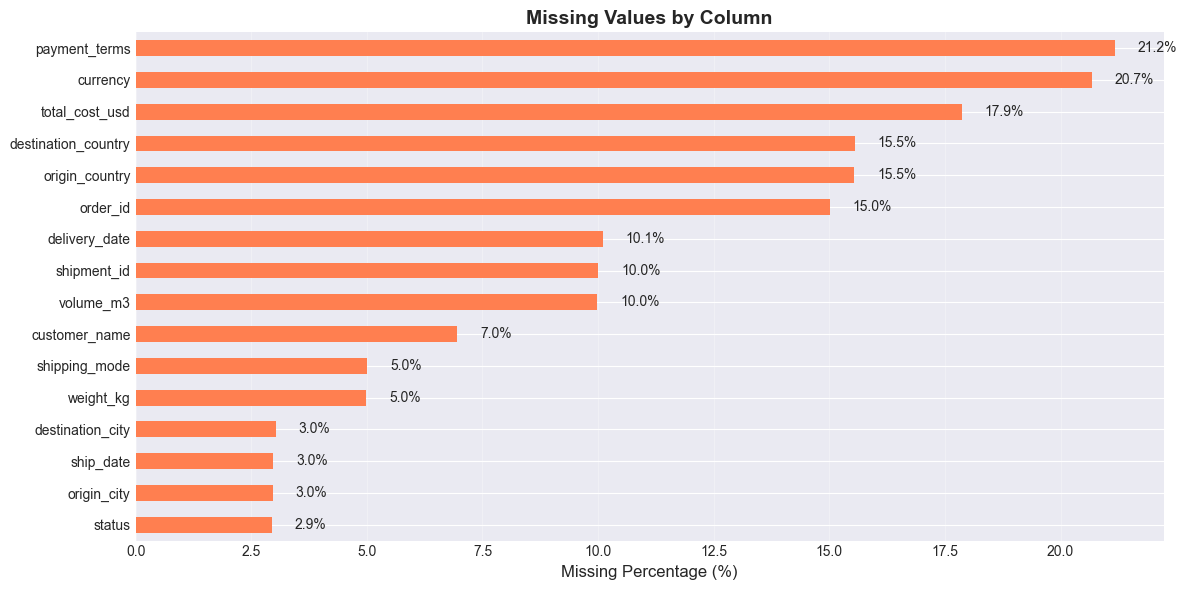

In [ ]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 10))
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)

missing_pct.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)', fontsize=12)
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(missing_pct):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

### Data Distribution Analysis

In [9]:
# Unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Unique Values in Categorical Columns:")
print("="*60)
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"\n{col}: {unique_count} unique values")
    if unique_count <= 10:
        print(df[col].value_counts())

Unique Values in Categorical Columns:

shipment_id: 325170 unique values

order_id: 286193 unique values

customer_name: 324 unique values

origin_city: 8 unique values
origin_city
BKK            48750
Phnompenh      48660
Saigon         48581
HCMC           48543
Phnom Penh     48507
Bangkok        48474
PP             48421
Ho Chi Minh    48208
Name: count, dtype: int64

destination_city: 8 unique values
destination_city
PP             48647
Phnom Penh     48628
Bangkok        48556
Saigon         48523
Phnompenh      48517
HCMC           48447
Ho Chi Minh    48395
BKK            48181
Name: count, dtype: int64

origin_country: 8 unique values
origin_country
VN          42499
VNM         42327
KHM         42293
KH          42262
Vietnam     42200
TH          42126
Cambodia    42063
Thailand    42060
Name: count, dtype: int64

destination_country: 8 unique values
destination_country
KHM         42491
Thailand    42269
Vietnam     42240
TH          42204
Cambodia    42183
VN          4

In [14]:
# 2. Fix the date formats automatically
# (Change 'ship_date' to whichever date column you are analyzing)
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce', format='mixed')

# 3. Check if any dates failed to parse (turned into NaT)
failed_dates = df['ship_date'].isna().sum()
if failed_dates > 0:
    print(f"⚠️ Warning: {failed_dates} rows had unreadable dates and were set to NaT.")
    print("="*60)

# 4. Now run your Date Range Analysis safely!
print("Date Range Analysis (Cleaned):")
print("="*60)
print(f"Start Date: {df['ship_date'].min().strftime('%Y-%m-%d')}")
print(f"End Date:   {df['ship_date'].max().strftime('%Y-%m-%d')}")

total_days = (df['ship_date'].max() - df['ship_date'].min()).days
print(f"Date Range: {total_days} days")

⚠️ Warning: 15737 rows had unreadable dates and were set to NaT.
Date Range Analysis (Cleaned):
Start Date: 2020-01-01
End Date:   2025-12-31
Date Range: 2191 days


In [15]:
# Count how many missing values are in each column
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
shipment_id            39998
order_id               60039
customer_name          27819
origin_city            11856
destination_city       12106
origin_country         62170
destination_country    62198
ship_date              15737
delivery_date          40384
weight_kg              19961
volume_m3              39936
shipping_mode          20042
status                 11784
base_cost_usd              0
surcharge_usd              0
total_cost_usd         71431
currency               82687
payment_terms          84698
created_at                 0
last_update                0
dtype: int64


In [16]:
# Count duplicate rows based on the unique Shipment ID
duplicate_count = df.duplicated(subset=['shipment_id']).sum()
print(f"Number of duplicate shipment IDs: {duplicate_count}")

Number of duplicate shipment IDs: 74829


In [17]:
# See all unique values in a column to spot inconsistencies
print(df['shipping_mode'].value_counts())
print(df['status'].value_counts())

shipping_mode
air            42469
trk            42374
sea            42343
Air Freight    42302
AIR            42242
TRK            42168
rail           42091
Sea            42086
truck          41883
Name: count, dtype: int64
status
in transit    39007
INTRANSIT     38935
lost          38902
delivered     38888
LOST          38842
DELIVERED     38802
??            38775
returned      38730
RETURNED      38713
Delivered     38622
Name: count, dtype: int64


In [ ]:
# Look at the minimum and maximum values for numeric columns
print(df[['weight_kg', 'volume_m3', 'total_cost_usd']].describe())

       volume_m3
count  360064.00
mean        2.02
std         0.96
min         0.00
25%         1.33
50%         2.00
75%         2.67
max         6.56
